# 02 - RFM Segmentation
Segment customers by Recency, Frequency, and Monetary value to identify who drives revenue and who is slipping away.

**Business question:** Which customer segments should marketing prioritize for retention vs. growth campaigns?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../scripts')
from rfm_segmentation import compute_rfm, score_rfm, label_segment, cluster_rfm

tx = pd.read_csv('../data/clean_transactions.csv')
rfm = compute_rfm(tx)
rfm.describe()

Matplotlib is building the font cache; this may take a moment.


,customer_id,recency_days,frequency,monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,200.331916,6.289384,2955.904092
std,1715.572666,209.338707,13.009406,14440.852686
min,12346.000000,0.000000,1.000000,2.950000
25%,13833.250000,25.000000,1.000000,342.280000
50%,15314.500000,95.000000,3.000000,867.740000
75%,16797.750000,379.000000,7.000000,2248.305000
max,18287.000000,738.000000,398.000000,580987.040000


## Score and segment customers

In [2]:
rfm = score_rfm(rfm)
rfm['segment'] = rfm.apply(label_segment, axis=1)
rfm = cluster_rfm(rfm)
rfm.head()

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_score,segment,cluster
0,12346,325,12,77556.46,2,4,4,244,At-Risk High Value,0
1,12347,1,8,4921.53,4,4,4,444,Champions,0
2,12348,74,5,2019.40,3,3,3,333,Champions,0
3,12349,18,4,4428.69,4,3,4,434,Champions,0
4,12350,309,1,334.40,2,1,1,211,Hibernating / Lost,1


## Segment distribution

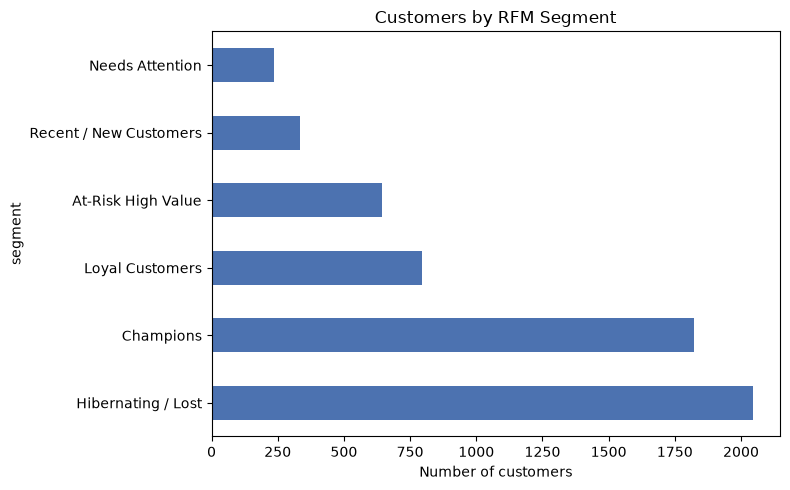

segment
Hibernating / Lost        2045
Champions                 1821
Loyal Customers            796
At-Risk High Value         643
Recent / New Customers     336
Needs Attention            237
Name: count, dtype: int64

In [3]:
segment_counts = rfm['segment'].value_counts()
segment_counts.plot(kind='barh', figsize=(8,5), color='#4C72B0')
plt.title('Customers by RFM Segment')
plt.xlabel('Number of customers')
plt.tight_layout()
plt.show()
segment_counts

## Revenue contribution by segment

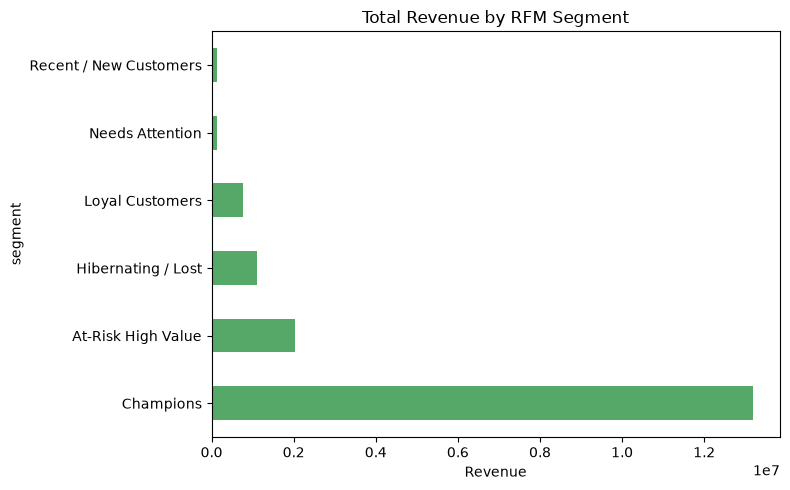

segment
Champions                 13186331.02
At-Risk High Value         2025600.27
Hibernating / Lost         1116794.60
Loyal Customers             776072.34
Needs Attention             139427.27
Recent / New Customers      130578.75
Name: monetary, dtype: float64

In [4]:
revenue_by_segment = rfm.groupby('segment')['monetary'].sum().sort_values(ascending=False)
revenue_by_segment.plot(kind='barh', figsize=(8,5), color='#55A868')
plt.title('Total Revenue by RFM Segment')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()
revenue_by_segment

In [5]:
rfm.to_csv('../data/rfm_segments.csv', index=False)
print('Saved ../data/rfm_segments.csv')

Saved ../data/rfm_segments.csv


## Key takeaways
- Fill in once run on the real dataset: e.g. 'Champions make up X% of customers but drive Y% of revenue'
- 'At-Risk High Value' customers are the top retention priority — high past spend, slipping recency
- Recommend: targeted win-back email campaign for At-Risk High Value; loyalty perks for Champions